<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4p/blob/main/05_stan_logistic_regression.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-reglin1-notebook)=
# Regressione logistica con Stan

In questo tutorial replicheremo con CmdStanPy la regressione logistica che in precedenza abbiamo svolto usando PyMC e Bambi. Useremo gli stessi dati usati in precedenza.

## Preparazione del Notebook

In [57]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats
from scipy.special import expit  # Funzione logistica
from cmdstanpy import cmdstan_path, CmdStanModel

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [3]:
def scale_columns(dataframe, columns_to_scale):
    # Work on a copy to avoid modifying the original DataFrame
    df_scaled = dataframe.copy()
    for column in columns_to_scale:
        # Scale each specified column individually
        df_scaled[column] = stats.zscore(df_scaled[column])
    return df_scaled

In [115]:
clinton_data = pd.read_csv("../data/clinton.csv")
clinton_data.dropna(inplace=True)
clinton_data = clinton_data.query("vote != 'someone_else'")
clinton_data.head()

,Unnamed: 0,vote,age,party_id
0,0,clinton,56,democrat
1,1,trump,65,republican
2,2,clinton,80,democrat
3,3,trump,38,republican
4,4,trump,60,republican


In [116]:
# Conversione dei valori nella colonna 'vote'
clinton_data['vote'] = clinton_data['vote'].replace({'clinton': 1, 'trump': 0})
clinton_data['vote'] = clinton_data['vote'].astype(int)
clinton_data.head()

/var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/ipykernel_55827/1878734763.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clinton_data['vote'] = clinton_data['vote'].replace({'clinton': 1, 'trump': 0})


,Unnamed: 0,vote,age,party_id
0,0,1,56,democrat
1,1,0,65,republican
2,2,1,80,democrat
3,3,0,38,republican
4,4,0,60,republican


In [83]:
columns_to_scale = ['age']
scaled_df = scale_columns(clinton_data, columns_to_scale)
scaled_df.head()

,Unnamed: 0,vote,age,party_id
0,0,1,0.392692,democrat
1,1,0,0.916229,republican
2,2,1,1.788790,democrat
3,3,0,-0.654382,republican
4,4,0,0.625375,republican


In [84]:
scaled_df['vote'] = pd.to_numeric(scaled_df['vote'], errors='coerce')
data_matrix = scaled_df[['vote']]
data_matrix.shape

(373, 1)

In [122]:
stan_data = {
    "N" : data_matrix.shape[0],
    "y" : clinton_data['vote'].astype(int),
    "x" : clinton_data["age"] 
}

In [123]:
stan_file = os.path.join('stan', 'logistic_regression.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=0> N;
  vector[N] x;
  array[N] int<lower=0, upper=1> y;
}
parameters {
  real alpha;
  real beta;
}
model {
  y ~ bernoulli_logit(alpha + beta * x);
}



In [124]:
model = CmdStanModel(stan_file=stan_file)
print(model)

CmdStanModel: name=logistic_regression
	 stan_file=/Users/corrado/_repositories/ds4p/chapter_5/stan/logistic_regression.stan
	 exe_file=/Users/corrado/_repositories/ds4p/chapter_5/stan/logistic_regression
	 compiler_options=stanc_options={}, cpp_options={}


In [126]:
fit = model.sample(data=stan_data)

15:53:57 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▉         | 00:00 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |██▎       | 00:00 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |████      | 00:00 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |██████▎   | 00:00 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |████████▏ | 00:00 Iteration: 1500 / 2000 [ 75%]  (Sampling)


chain 1 |██████████| 00:00 Iteration: 1900 / 2000 [ 95%]  (Sampling)

chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed                       
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       


15:53:58 - cmdstanpy - INFO - CmdStan done processing.


In [127]:
az.summary(fit, var_names=(["alpha", "beta"]), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.188,0.327,0.555,1.834,0.012,0.009,734.0,836.0,1.01
beta,-0.018,0.006,-0.030,-0.006,0.000,0.000,723.0,733.0,1.01


In [128]:
new_data = pd.DataFrame({
    "age": np.linspace(18, 90, 100)
})
new_data

,age
0,18.000000
1,18.727273
2,19.454545
3,20.181818
4,20.909091
...,...
95,87.090909
96,87.818182
97,88.545455
98,89.272727


In [129]:
alpha = fit.stan_variable('alpha').mean()
beta = fit.stan_variable('beta').mean() 

In [130]:
beta

-0.01768601428825

In [131]:
# Calcola le probabilità logit per ogni età in `new_data`
logit_p = alpha + new_data['age'] * beta
logit_p

0     0.869710
1     0.856847
2     0.843985
3     0.831122
4     0.818260
        ...   
95   -0.352233
96   -0.365096
97   -0.377958
98   -0.390821
99   -0.403683
Name: age, Length: 100, dtype: float64

In [132]:
new_data['logit_p'] = logit_p

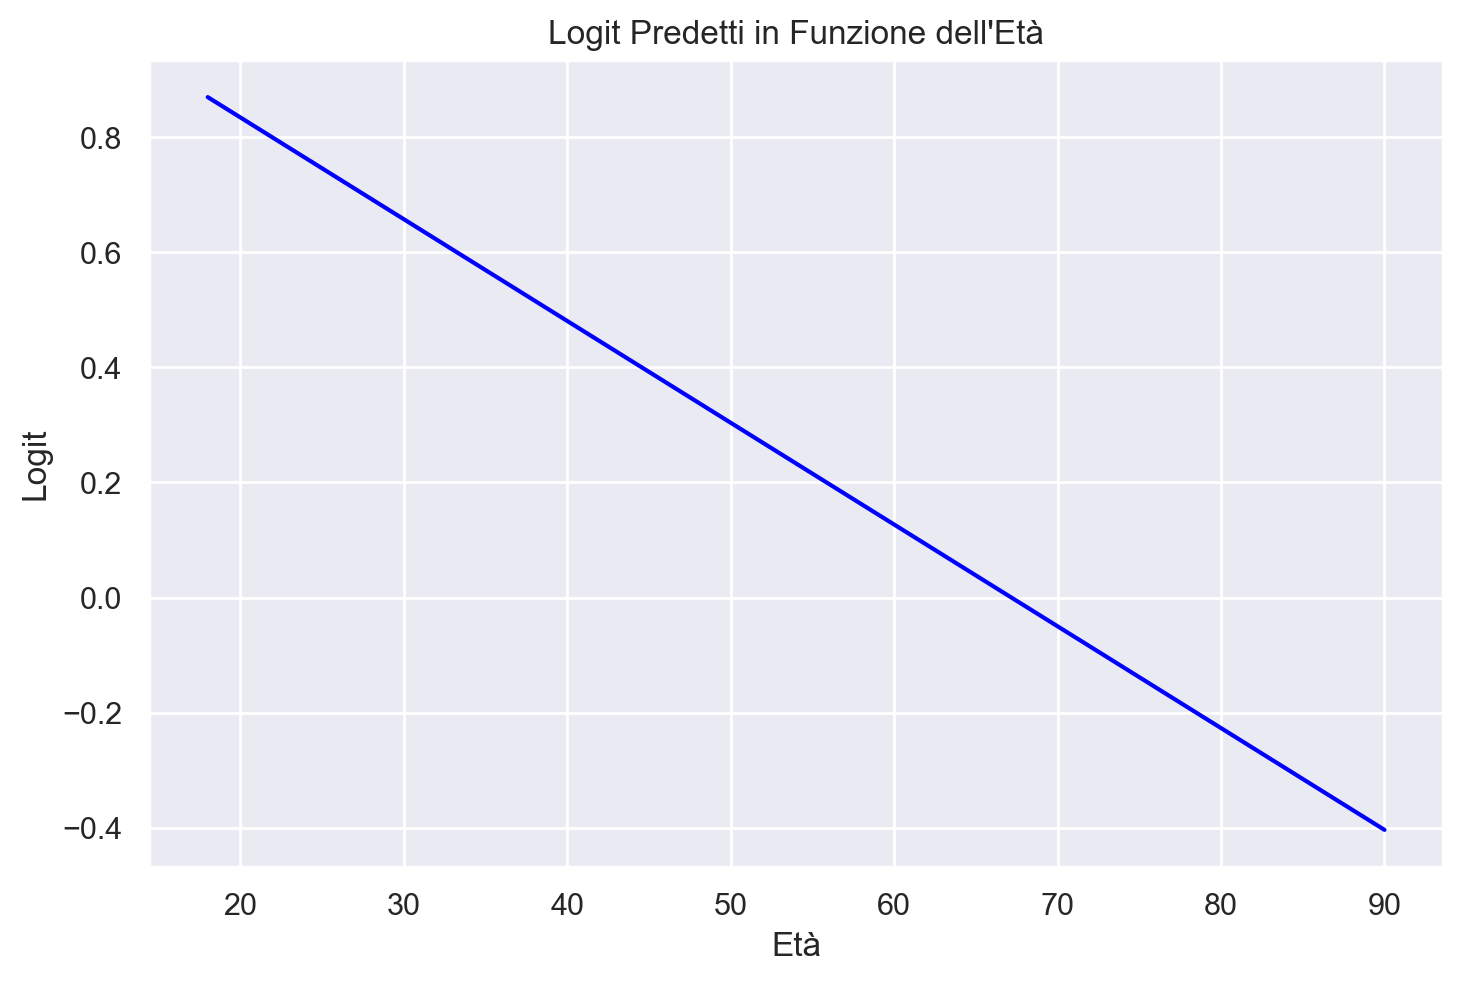

In [137]:
plt.plot(new_data['age'], new_data['logit_p'], linestyle='-', color='blue')  # Plot con marcatori e linea

plt.title('Logit Predetti in Funzione dell\'Età')  # Titolo del grafico
plt.xlabel('Età')  # Etichetta asse x
plt.ylabel('Logit')  # Etichetta asse y
plt.show() 

In [134]:
# Converti logit in probabilità usando la funzione logistica (expit)
prob = expit(logit_p)
# Aggiungi le probabilità calcolate a `new_data`
new_data['prob'] = prob

In [135]:
new_data.describe()

,age,logit_p,prob
count,100.000000,100.000000,100.000000
mean,54.000000,0.233013,0.556096
std,21.099267,0.373162,0.090277
min,18.000000,-0.403683,0.400428
25%,36.000000,-0.085335,0.478679
50%,54.000000,0.233013,0.557991
75%,72.000000,0.551362,0.634450
max,90.000000,0.869710,0.704685


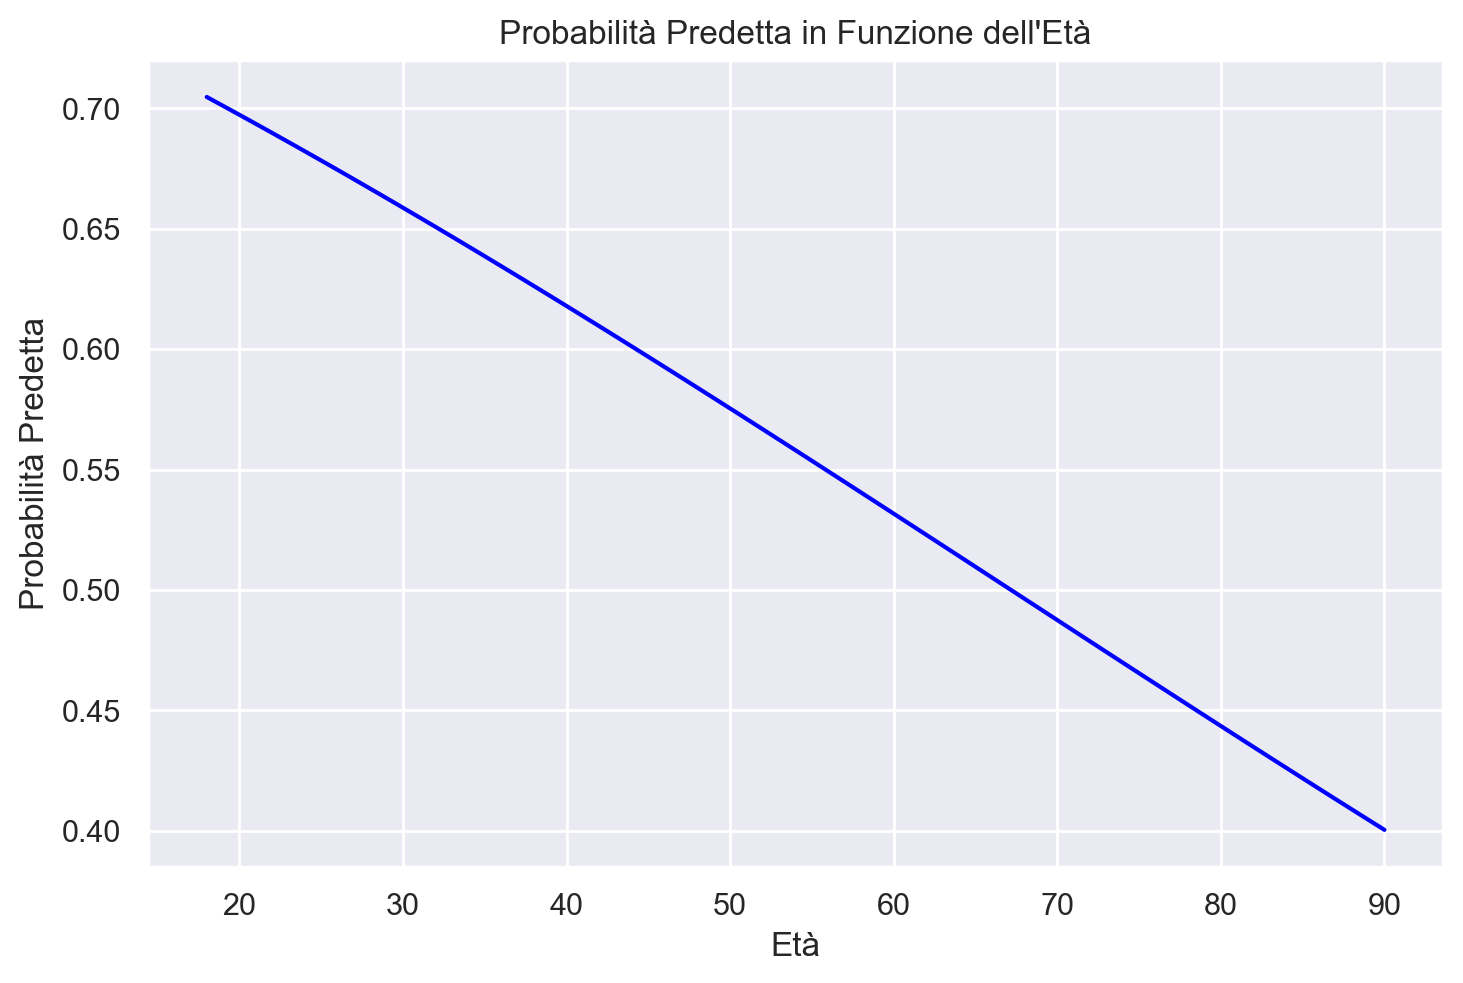

In [136]:
plt.plot(new_data['age'], new_data['prob'], linestyle='-', color='blue')  # Plot con marcatori e linea

plt.title('Probabilità Predetta in Funzione dell\'Età')  # Titolo del grafico
plt.xlabel('Età')  # Etichetta asse x
plt.ylabel('Probabilità Predetta')  # Etichetta asse y
plt.show() 

## Watermark

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p cmdstanp